# Hotel Booking Cancellation Prediction — Combined Final Notebook

This notebook merges everything useful from the four earlier notebooks into **one
run-top-to-bottom pipeline**, and drops what shouldn't be there:

**Kept / combined:**
- Full EDA (shape, dtypes, missing values, duplicates, `describe()`)
- Cleaning (duplicates dropped, missing values imputed)
- Feature engineering (`total_guests`, `total_stay`, `total_cost`)
- **Data-leakage fix**: `reservation_status` and `reservation_status_date` are dropped
  before training — they only exist *after* the outcome is known, which is why the
  original notebook scored ~100% accuracy.
- A multi-model comparison (Logistic Regression, Decision Tree, Random Forest, Extra
  Trees, KNN, Naive Bayes, MLP, Bagging, AdaBoost, Gradient Boosting) with train/test
  gap and overfit flagging
- Feature-selection experiment (`SelectKBest`, top 15 features) for comparison
- The **final, regularized, hyperparameter-tuned Random Forest** (the best version
  across the two RF tuning notebooks — it constrains tree depth / leaf size so the
  model doesn't memorize the training set) with full evaluation, feature importance,
  a 10-record sanity check, and saved model artifacts

**Removed:**
- **SVM (`SVC(probability=True)`)** — on this dataset's ~119,000 rows, SVM training
  (plus the internal 5-fold cross-validation) scales very poorly and can run for a
  very long time for essentially no benefit over the tree-based models. It's cut
  from the model comparison.
- The old **leaky** original notebook (`Untitled__2_.ipynb`), which never dropped
  `reservation_status` — it's a duplicate of the leaky version this project already
  moved past.
- The old **un-regularized** Random Forest tuning notebook
  (`RandomForest_HyperparameterTuning.ipynb`) — its search space allowed
  `max_depth=None` / `bootstrap=False`, which overfit (14-point train/test gap). It's
  superseded by the regularized version kept below.


## 1. Imports

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## 2. Load Data

In [2]:
# Works whether the CSV is named "hotel_bookings.csv" (Colab-style path) or
# "hotel_bookings__1_.csv" (the name it has when downloaded from this chat).
candidates = [
    "hotel_bookings.csv",
    "/content/hotel_bookings.csv",
    "hotel_bookings__1_.csv",
    "/mnt/user-data/uploads/hotel_bookings__1_.csv",
]
DATA_PATH = next((p for p in candidates if os.path.exists(p)), candidates[0])

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded from: {DATA_PATH}")
df.head()


Dataset loaded from: hotel_bookings.csv


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03


## 3. Exploratory Data Analysis

In [3]:
print("Shape of Dataset :", df.shape)

print("\nColumns\n")
print(df.columns.tolist())

print("\nData Types\n")
print(df.dtypes)

print("\nMissing Values\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate Rows :", df.duplicated().sum())


Shape of Dataset : (36553, 32)

Columns

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data Types

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights          

In [4]:
df.describe(include='all')


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,36553,36553.000000,36553.000000,36553.000000,36553,36553.000000,36553.000000,36553.000000,36553.000000,36553.000000,...,36553,28702.000000,3003.000000,36552.000000,36552,36552.000000,36552.000000,36552.000000,36552,36552
unique,1,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,4,NaN,NaN,NaN,4,NaN,NaN,NaN,3,904
top,Resort Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2017-01-19
freq,36553,NaN,NaN,NaN,3844,NaN,NaN,NaN,NaN,NaN,...,34692,NaN,NaN,NaN,27533,NaN,NaN,NaN,25431,147
mean,NaN,0.304243,89.887615,2016.037152,NaN,27.089815,15.731294,1.167346,3.077121,1.855689,...,NaN,217.294962,240.226773,0.572445,NaN,89.224953,0.133125,0.583662,NaN,NaN
std,NaN,0.460092,96.228133,0.700490,NaN,14.596870,8.868351,1.147253,2.462443,0.719833,...,NaN,87.363623,125.199285,7.740183,NaN,57.630376,0.345940,0.790185,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,10.000000,2016.000000,NaN,15.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,240.000000,154.000000,0.000000,NaN,48.000000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,54.000000,2016.000000,NaN,28.000000,16.000000,1.000000,3.000000,2.000000,...,NaN,240.000000,223.000000,0.000000,NaN,72.000000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,149.000000,2017.000000,NaN,39.000000,23.000000,2.000000,5.000000,2.000000,...,NaN,242.000000,329.000000,0.000000,NaN,114.017500,0.000000,1.000000,NaN,NaN


## 4. Cleaning: Duplicates & Missing Values

In [5]:
print("Duplicate Rows Before :", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate Rows After  :", df.duplicated().sum())


Duplicate Rows Before : 5934
Duplicate Rows After  : 0


In [6]:
# Fill children with median
if 'children' in df.columns:
    df['children'] = df['children'].fillna(df['children'].median())

# Fill country with mode
if 'country' in df.columns:
    df['country'] = df['country'].fillna(df['country'].mode()[0])

# Fill agent / company with 0 (no agent / no company)
if 'agent' in df.columns:
    df['agent'] = df['agent'].fillna(0)

if 'company' in df.columns:
    df['company'] = df['company'].fillna(0)

print("Remaining missing values:")
print(df.isnull().sum().sum())


Remaining missing values:
7


## 5. Feature Engineering

In [7]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_cost"] = df["adr"] * df["total_stay"]

df[["total_guests", "total_stay", "total_cost"]].head()


,total_guests,total_stay,total_cost
0,2,0,0.0
1,2,0,0.0
2,1,1,75.0
3,1,1,75.0
4,2,2,196.0


## 6. Remove Data Leakage

`reservation_status` (Canceled / Check-Out / No-Show) and `reservation_status_date`
are only known **after** the booking outcome is decided — they directly encode the
target. They must be dropped before training, or the model will "cheat" and score
close to 100% while being useless for predicting cancellations ahead of time.

In [8]:
leak_cols = ["reservation_status", "reservation_status_date"]
leak_cols_present = [c for c in leak_cols if c in df.columns]
print("Dropping leakage columns:", leak_cols_present)

df = df.drop(columns=leak_cols_present)
print("Remaining columns:", df.shape[1])


Dropping leakage columns: ['reservation_status', 'reservation_status_date']
Remaining columns: 33


## 7. Encode Categorical Columns

In [9]:
encoder = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

print("Encoding completed for:", list(cat_cols))


Encoding completed for: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


## 8. Train/Test Split & Scaling

In [10]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

assert not any(c in X.columns for c in leak_cols), "Leakage column found in X!"

print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


(30619, 32) (30619,)
Train shape: (24495, 32)
Test shape : (6124, 32)


## 9. Model Comparison

Trains every model below on the full feature set and records accuracy, precision,
recall, F1, ROC AUC, 5-fold CV accuracy, and the train/test accuracy gap (used to
flag overfitting).

> **Note:** SVM (`SVC`) was intentionally left out here. On ~119k rows it is by far
> the slowest model to train (especially with `probability=True` and 5-fold CV on
> top), and it doesn't outperform the tree-based models on this dataset — so it's
> not worth the runtime.

In [12]:
from sklearn.impute import SimpleImputer

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP": MLPClassifier(max_iter=500),
    "Bagging": BaggingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []

# Impute any remaining NaNs in the scaled data before training models
imputer = SimpleImputer(strategy='median')
X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)
X_test_scaled_imputed = imputer.transform(X_test_scaled)

for name, model in models.items():
    print("=" * 60)
    print(name)

    model.fit(X_train_scaled_imputed, y_train)

    y_pred = model.predict(X_test_scaled_imputed)
    y_prob = model.predict_proba(X_test_scaled_imputed)[:, 1] if hasattr(model, "predict_proba") else None

    train_acc = model.score(X_train_scaled_imputed, y_train)
    test_acc = model.score(X_test_scaled_imputed, y_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    cv = cross_val_score(model, X_train_scaled_imputed, y_train, cv=5).mean()

    diff = train_acc - test_acc
    if diff <= 0.05:
        status = "Good Fit"
    elif diff <= 0.10:
        status = "Slight Overfit"
    else:
        status = "Overfitting"

    results.append([name, train_acc, test_acc, accuracy, precision, recall, f1, roc, cv, diff, status])

    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"ROC AUC        : {roc:.4f}" if not np.isnan(roc) else "ROC AUC        : N/A")
    print(f"CV Score       : {cv:.4f}")
    print(f"Status         : {status}")

Logistic Regression
Train Accuracy : 0.8315
Test Accuracy  : 0.8307
Precision      : 0.7159
Recall         : 0.5799
F1 Score       : 0.6408
ROC AUC        : 0.8891
CV Score       : 0.8311
Status         : Good Fit
Decision Tree
Train Accuracy : 0.9984
Test Accuracy  : 0.8568
Precision      : 0.7224
Recall         : 0.7310
F1 Score       : 0.7267
ROC AUC        : 0.8172
CV Score       : 0.8590
Status         : Overfitting
Random Forest
Train Accuracy : 0.9984
Test Accuracy  : 0.9032
Precision      : 0.8446
Recall         : 0.7699
F1 Score       : 0.8055
ROC AUC        : 0.9506
CV Score       : 0.8984
Status         : Slight Overfit
Extra Trees
Train Accuracy : 0.9984
Test Accuracy  : 0.8929
Precision      : 0.8323
Recall         : 0.7373
F1 Score       : 0.7819
ROC AUC        : 0.9442
CV Score       : 0.8906
Status         : Overfitting
KNN
Train Accuracy : 0.8983
Test Accuracy  : 0.8444
Precision      : 0.7084
Recall         : 0.6840
F1 Score       : 0.6960
ROC AUC        : 0.8827
CV S

In [13]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Train Accuracy", "Test Accuracy", "Accuracy",
    "Precision", "Recall", "F1 Score", "ROC AUC",
    "Cross Validation", "Difference", "Status"
])

results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1 Score,ROC AUC,Cross Validation,Difference,Status
0,Random Forest,0.998449,0.903168,0.903168,0.844567,0.769906,0.805510,0.950628,0.898428,0.095281,Slight Overfit
1,Extra Trees,0.998449,0.892880,0.892880,0.832272,0.737304,0.781915,0.944242,0.890590,0.105568,Overfitting
2,Gradient Boosting,0.896673,0.892064,0.892064,0.826573,0.741066,0.781488,0.947347,0.893244,0.004609,Good Fit
3,Bagging,0.991304,0.890921,0.890921,0.813812,0.753605,0.782552,0.931969,0.889978,0.100383,Overfitting
4,MLP,0.927373,0.881777,0.881777,0.768000,0.782445,0.775155,0.940634,0.874546,0.045596,Good Fit
5,Decision Tree,0.998449,0.856793,0.856793,0.722429,0.731034,0.726706,0.817201,0.858951,0.141656,Overfitting
6,KNN,0.898347,0.844383,0.844383,0.708442,0.684013,0.696013,0.882739,0.843723,0.053964,Slight Overfit
7,AdaBoost,0.843274,0.838831,0.838831,0.743981,0.581191,0.652587,0.898007,0.841804,0.004443,Good Fit
8,Logistic Regression,0.831476,0.830666,0.830666,0.715944,0.579937,0.640804,0.889127,0.831108,0.000810,Good Fit
9,Naive Bayes,0.494795,0.500490,0.500490,0.339755,0.973041,0.503651,0.822358,0.495734,-0.005695,Good Fit


In [14]:
results_df.to_csv("ML_Model_Comparison.csv", index=False)
print("Results saved to ML_Model_Comparison.csv")


Results saved to ML_Model_Comparison.csv


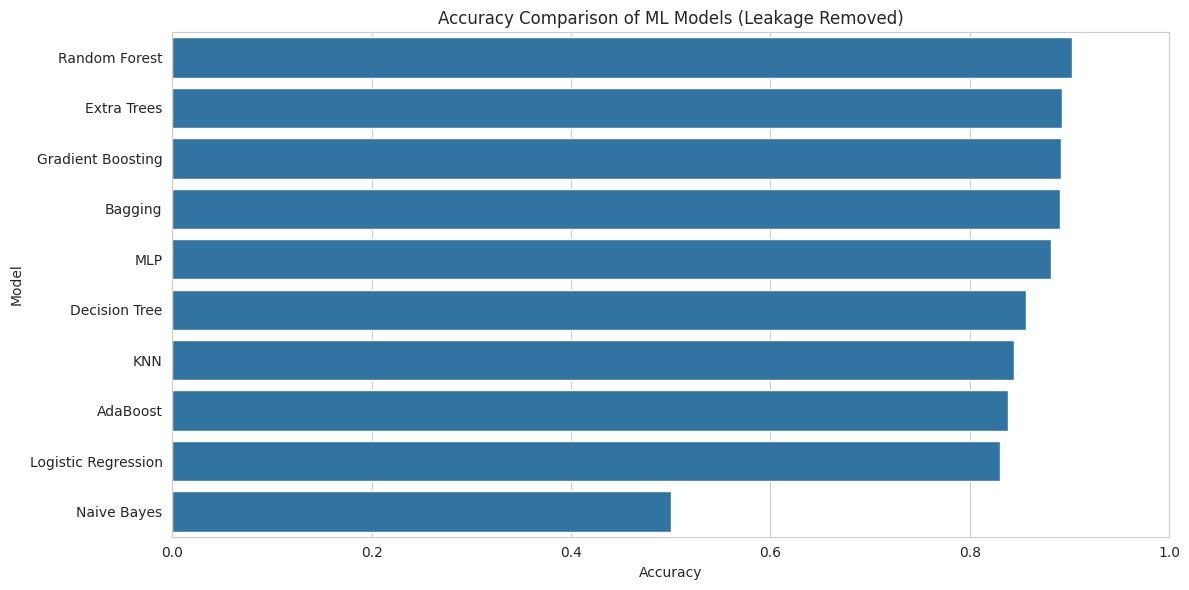

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.title("Accuracy Comparison of ML Models (Leakage Removed)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


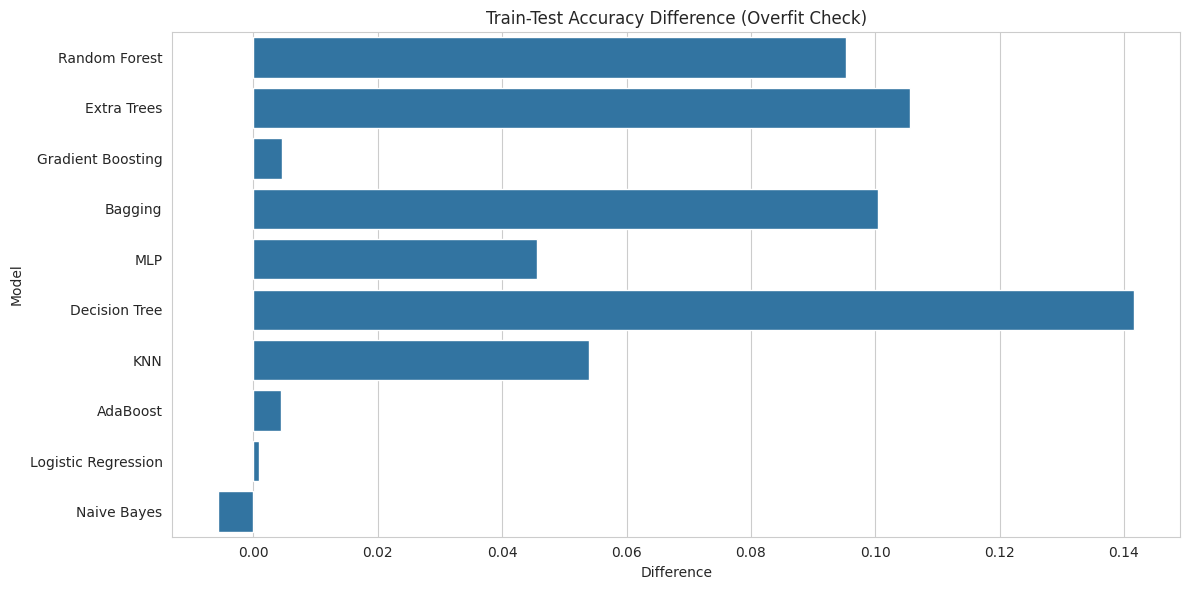

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Difference", y="Model")
plt.title("Train-Test Accuracy Difference (Overfit Check)")
plt.tight_layout()
plt.show()


## 10. Best Model From Comparison — Deep-Dive Evaluation

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best Model :", best_model_name)

y_pred = best_model.predict(X_test_scaled)

print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred))


Best Model : Random Forest
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      4529
           1       0.84      0.77      0.81      1595

    accuracy                           0.90      6124
   macro avg       0.88      0.86      0.87      6124
weighted avg       0.90      0.90      0.90      6124



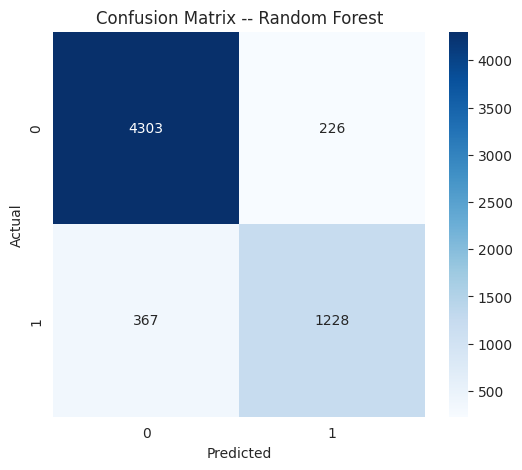

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix -- {best_model_name}")
plt.show()


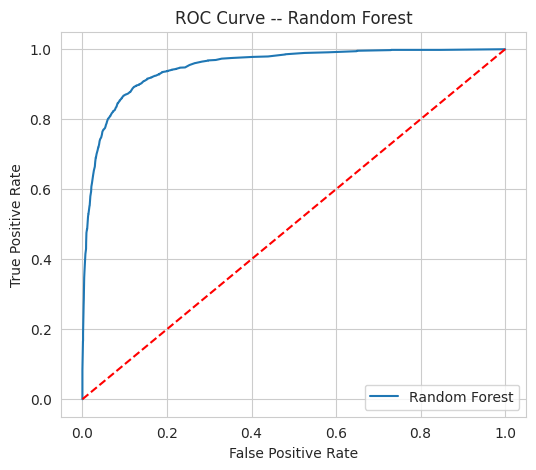

In [19]:
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=best_model_name)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve -- {best_model_name}")
    plt.legend()
    plt.show()


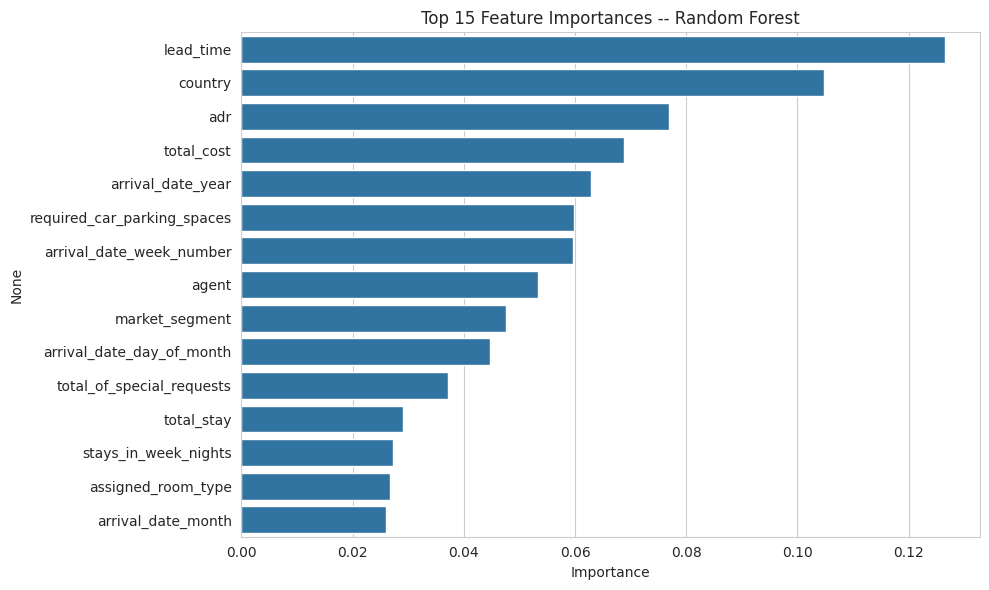

lead_time                      0.126513
country                        0.104797
adr                            0.076920
total_cost                     0.068774
arrival_date_year              0.062808
required_car_parking_spaces    0.059895
arrival_date_week_number       0.059699
agent                          0.053284
market_segment                 0.047660
arrival_date_day_of_month      0.044699
total_of_special_requests      0.037209
total_stay                     0.029113
stays_in_week_nights           0.027315
assigned_room_type             0.026760
arrival_date_month             0.025928
dtype: float64


In [20]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"Top 15 Feature Importances -- {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(importances)


## 11. Feature Selection Experiment (SelectKBest, top 15)

Checks whether cutting down to the 15 statistically strongest features changes
model performance meaningfully.

In [22]:
from sklearn.impute import SimpleImputer

# Impute any remaining NaNs in X before feature selection
imputer_fs = SimpleImputer(strategy='median')
X_imputed = imputer_fs.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

selector = SelectKBest(score_func=f_classif, k=15)
X_new = selector.fit_transform(X_imputed, y)
selected_cols = X_imputed.columns[selector.get_support()]
print("Selected features:", list(selected_cols))

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_new, y, test_size=0.20, random_state=42, stratify=y
)

scaler_fs = StandardScaler()
X_train_fs = scaler_fs.fit_transform(X_train_fs)
X_test_fs = scaler_fs.transform(X_test_fs)

Selected features: ['lead_time', 'arrival_date_year', 'stays_in_weekend_nights', 'stays_in_week_nights', 'children', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'agent', 'adr', 'required_car_parking_spaces', 'total_guests', 'total_stay', 'total_cost']


In [23]:
feature_results = []

for name, model in models.items():
    print("=" * 60)
    print(name)

    model.fit(X_train_fs, y_train_fs)
    pred = model.predict(X_test_fs)
    prob = model.predict_proba(X_test_fs)[:, 1] if hasattr(model, "predict_proba") else None

    train_acc = model.score(X_train_fs, y_train_fs)
    test_acc = model.score(X_test_fs, y_test_fs)
    accuracy = accuracy_score(y_test_fs, pred)
    precision = precision_score(y_test_fs, pred)
    recall = recall_score(y_test_fs, pred)
    f1 = f1_score(y_test_fs, pred)
    roc = roc_auc_score(y_test_fs, prob) if prob is not None else np.nan
    cv = cross_val_score(model, X_train_fs, y_train_fs, cv=5).mean()

    diff = train_acc - test_acc
    if diff <= 0.05:
        status = "Good Fit"
    elif diff <= 0.10:
        status = "Slight Overfit"
    else:
        status = "Overfitting"

    feature_results.append([name, train_acc, test_acc, accuracy, precision, recall, f1, roc, cv, diff, status])

feature_results_df = pd.DataFrame(feature_results, columns=[
    "Model", "Train Accuracy", "Test Accuracy", "Accuracy",
    "Precision", "Recall", "F1", "ROC", "Cross Validation", "Difference", "Status"
])
feature_results_df = feature_results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
feature_results_df.to_csv("Feature_Selection_Results.csv", index=False)
feature_results_df


Logistic Regression
Decision Tree
Random Forest
Extra Trees
KNN
Naive Bayes
MLP
Bagging
AdaBoost
Gradient Boosting


,Model,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1,ROC,Cross Validation,Difference,Status
0,Random Forest,0.994448,0.863651,0.863651,0.756410,0.702821,0.728632,0.925978,0.866871,0.130797,Overfitting
1,Extra Trees,0.994448,0.859569,0.859569,0.748815,0.693417,0.720052,0.907304,0.856175,0.134879,Overfitting
2,Gradient Boosting,0.864789,0.859242,0.859242,0.753985,0.682132,0.716261,0.925138,0.862666,0.005546,Good Fit
3,Bagging,0.985956,0.854180,0.854180,0.737805,0.682759,0.709215,0.909553,0.857277,0.131776,Overfitting
4,MLP,0.870137,0.849608,0.849608,0.720261,0.690909,0.705280,0.915352,0.852664,0.020529,Good Fit
5,Decision Tree,0.994448,0.832952,0.832952,0.677200,0.685266,0.681209,0.786479,0.830700,0.161496,Overfitting
6,KNN,0.883282,0.831319,0.831319,0.685601,0.650784,0.667739,0.876798,0.830945,0.051963,Slight Overfit
7,AdaBoost,0.828210,0.820542,0.820542,0.697138,0.549843,0.614791,0.876902,0.828577,0.007668,Good Fit
8,Logistic Regression,0.810247,0.809602,0.809602,0.681934,0.504075,0.579668,0.853113,0.809675,0.000645,Good Fit
9,Naive Bayes,0.453644,0.459014,0.459014,0.323975,0.991223,0.488340,0.795886,0.453929,-0.005370,Good Fit


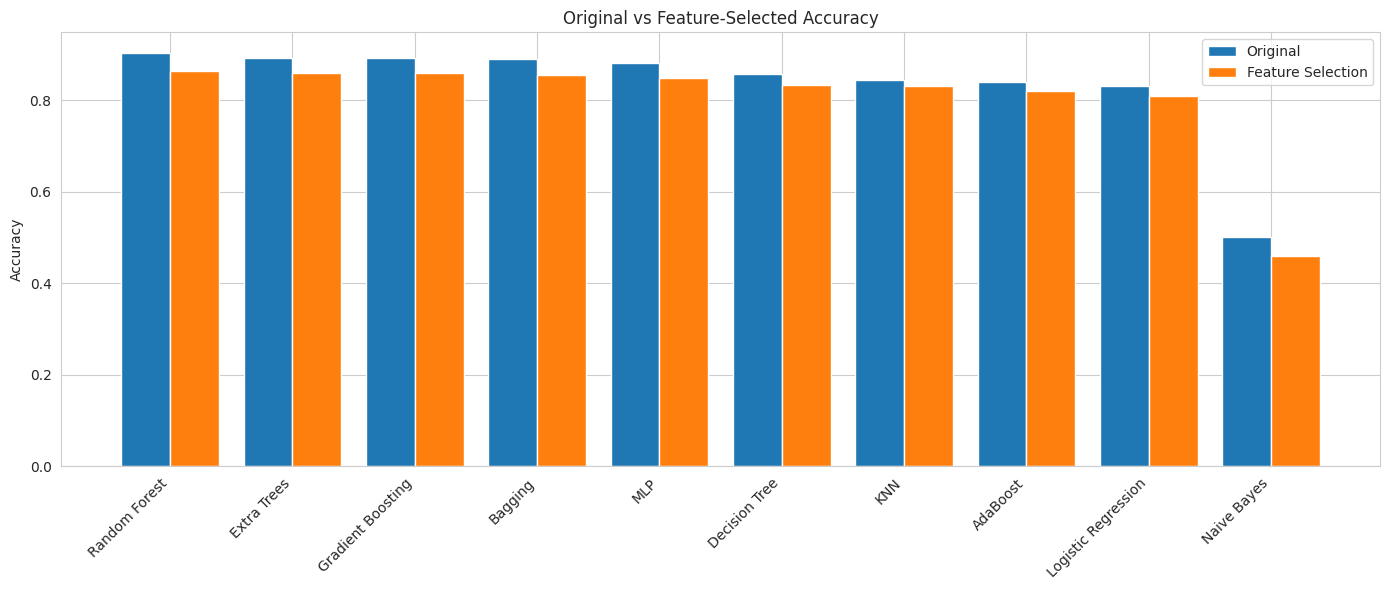

,Model,Accuracy (Original),Accuracy (Feature Selected)
0,Random Forest,0.903168,0.863651
1,Extra Trees,0.892880,0.859569
2,Gradient Boosting,0.892064,0.859242
3,Bagging,0.890921,0.854180
4,MLP,0.881777,0.849608
5,Decision Tree,0.856793,0.832952
6,KNN,0.844383,0.831319
7,AdaBoost,0.838831,0.820542
8,Logistic Regression,0.830666,0.809602
9,Naive Bayes,0.500490,0.459014


In [24]:
comparison = results_df[["Model", "Accuracy"]].merge(
    feature_results_df[["Model", "Accuracy"]],
    on="Model",
    suffixes=(" (Original)", " (Feature Selected)")
)

x = np.arange(len(comparison))
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, comparison["Accuracy (Original)"], width=0.4, label="Original")
plt.bar(x + 0.2, comparison["Accuracy (Feature Selected)"], width=0.4, label="Feature Selection")
plt.xticks(x, comparison["Model"], rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Original vs Feature-Selected Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

comparison


## 12. Final Model: Regularized, Hyperparameter-Tuned Random Forest

This is the deployable model. It uses the **full feature set** (no feature
selection — more robust across the whole dataset) and searches hyperparameters
with a **regularized search space**, so it can't land on the memorization-prone
combination (`max_depth=None`, `bootstrap=False`, tiny leaves) that overfit in the
earlier tuning attempt (14-point train/test accuracy gap for a +0.15% accuracy
gain — not a good trade).

Constraints baked into the search space:
- `bootstrap` is always `True` (each tree only sees a random subsample of rows)
- `max_depth` is capped (no unlimited-depth trees)
- `min_samples_leaf` / `min_samples_split` have a higher floor (leaves can't be
  built from just 1–2 samples)

In [25]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [6, 8, 10, 12, 15],           # capped -- no unlimited depth
    "min_samples_split": [10, 15, 20, 30],      # raised floor
    "min_samples_leaf": [4, 6, 8, 10],          # raised floor -- prevents tiny memorizing leaves
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True],                        # always sample -- adds regularization
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters Found:")
print(random_search.best_params_)
print("\nBest Cross-Validation Accuracy :", round(random_search.best_score_, 4))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters Found:
{'n_estimators': 400, 'min_samples_split': 30, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': None, 'bootstrap': True}

Best Cross-Validation Accuracy : 0.895


### Train/Test Gap Across the Top Candidates

Rather than blindly taking whichever candidate scored highest on CV accuracy, look
at each candidate's train vs. validation score gap too, to confirm we're not
quietly picking an overfit model again.

In [26]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results["gap"] = cv_results["mean_train_score"] - cv_results["mean_test_score"]

summary_cols = ["params", "mean_train_score", "mean_test_score", "gap", "rank_test_score"]
top10 = cv_results.sort_values("rank_test_score").head(10)[summary_cols]

pd.set_option("display.max_colwidth", None)
top10


,params,mean_train_score,mean_test_score,gap,rank_test_score
15,"{'n_estimators': 400, 'min_samples_split': 30, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': None, 'bootstrap': True}",0.918524,0.895040,0.023484,1
26,"{'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': None, 'bootstrap': True}",0.911574,0.892019,0.019555,2
18,"{'n_estimators': 400, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 15, 'class_weight': None, 'bootstrap': True}",0.915146,0.891529,0.023617,3
17,"{'n_estimators': 300, 'min_samples_split': 30, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 12, 'class_weight': None, 'bootstrap': True}",0.907103,0.890876,0.016228,4
11,"{'n_estimators': 200, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': None, 'bootstrap': True}",0.911543,0.890222,0.021321,5
8,"{'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': None, 'bootstrap': True}",0.911502,0.890141,0.021362,6
7,"{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 12, 'class_weight': None, 'bootstrap': True}",0.911758,0.890059,0.021698,7
16,"{'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': 'balanced', 'bootstrap': True}",0.920188,0.885201,0.034987,8
5,"{'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None, 'bootstrap': True}",0.895275,0.882711,0.012564,9
27,"{'n_estimators': 400, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None, 'bootstrap': True}",0.896428,0.882629,0.013799,10


In [27]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

train_acc = best_rf.score(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
cv_score = cross_val_score(best_rf, X_train_scaled, y_train, cv=5).mean()

diff = train_acc - test_acc
if diff <= 0.05:
    status = "Good Fit"
elif diff <= 0.10:
    status = "Slight Overfit"
else:
    status = "Overfitting"

print("=" * 60)
print("FINAL Random Forest -- Regularized & Tuned")
print("=" * 60)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC AUC        : {roc:.4f}")
print(f"CV Score       : {cv_score:.4f}")
print(f"Train/Test Gap : {diff:.4f}")
print(f"Status         : {status}")


FINAL Random Forest -- Regularized & Tuned
Train Accuracy : 0.9178
Test Accuracy  : 0.8961
Precision      : 0.8452
Recall         : 0.7361
F1 Score       : 0.7869
ROC AUC        : 0.9493
CV Score       : 0.8950
Train/Test Gap : 0.0216
Status         : Good Fit


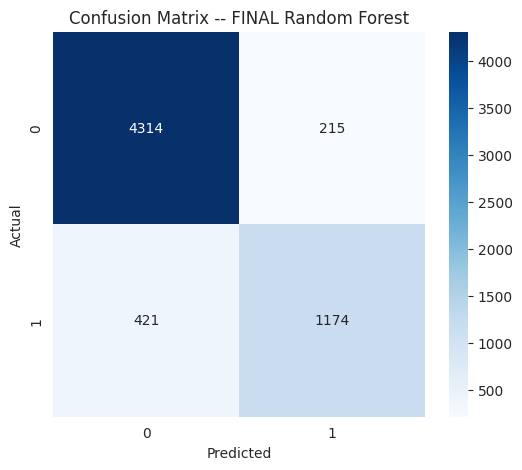

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      4529
           1       0.85      0.74      0.79      1595

    accuracy                           0.90      6124
   macro avg       0.88      0.84      0.86      6124
weighted avg       0.89      0.90      0.89      6124



In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -- FINAL Random Forest")
plt.show()

print(classification_report(y_test, y_pred))


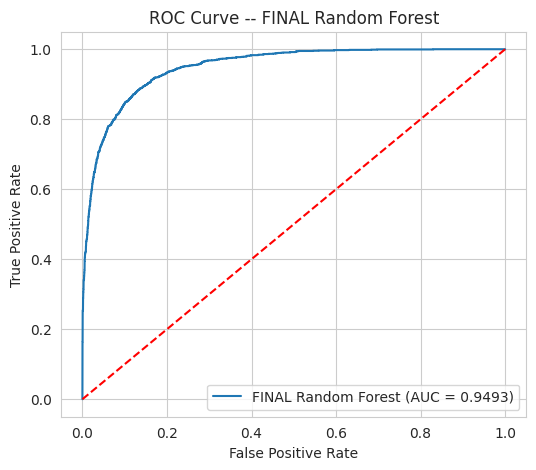

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"FINAL Random Forest (AUC = {roc:.4f})")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve -- FINAL Random Forest")
plt.legend()
plt.show()


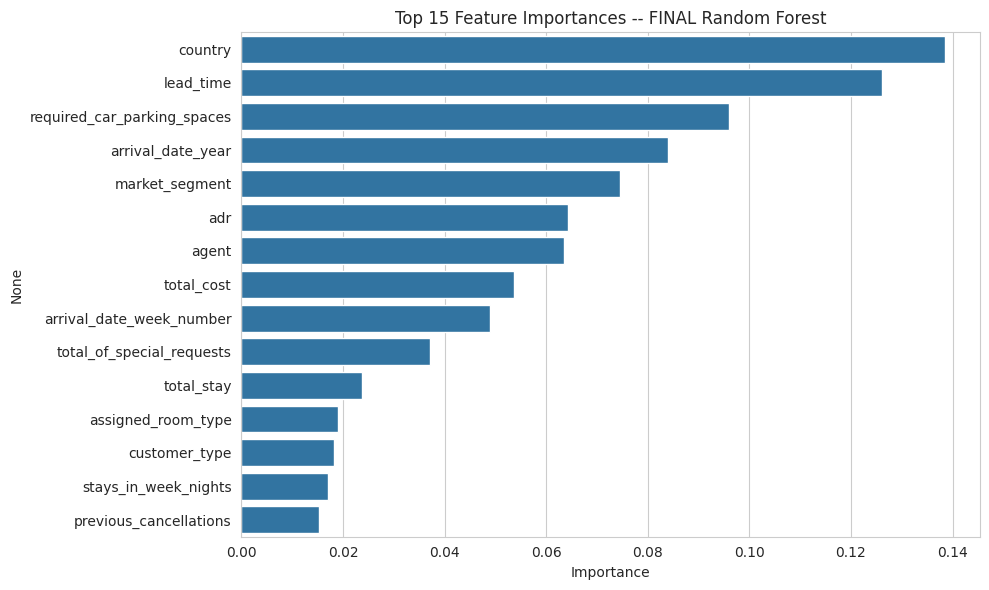

country                        0.138477
lead_time                      0.126090
required_car_parking_spaces    0.096033
arrival_date_year              0.084073
market_segment                 0.074550
adr                            0.064368
agent                          0.063512
total_cost                     0.053570
arrival_date_week_number       0.048989
total_of_special_requests      0.037076
total_stay                     0.023746
assigned_room_type             0.018937
customer_type                  0.018260
stays_in_week_nights           0.017086
previous_cancellations         0.015190
dtype: float64


In [30]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 Feature Importances -- FINAL Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances)


## 13. Sanity Check: Test the Final Model on 10 Random Records

In [31]:
sample_data = df.sample(n=10, random_state=42)

X_sample = sample_data.drop("is_canceled", axis=1)
y_actual = sample_data["is_canceled"]
X_sample_scaled = scaler.transform(X_sample)

y_pred_sample = best_rf.predict(X_sample_scaled)
y_prob_sample = best_rf.predict_proba(X_sample_scaled)[:, 1]

result_df = sample_data.copy()
result_df["Actual"] = y_actual.values
result_df["Predicted"] = y_pred_sample
result_df["Correct"] = result_df["Actual"] == result_df["Predicted"]
result_df["Probability"] = y_prob_sample

label_map = {0: "Not Cancelled", 1: "Cancelled"}
result_df["Actual Label"] = result_df["Actual"].map(label_map)
result_df["Predicted Label"] = result_df["Predicted"].map(label_map)

display_columns = ["Actual", "Predicted", "Actual Label", "Predicted Label", "Probability", "Correct"]
print(result_df[display_columns])

correct = result_df["Correct"].sum()
print("\n" + "=" * 60)
print("Correct Predictions :", correct)
print("Wrong Predictions   :", 10 - correct)
print("Sample Accuracy     :", round((correct / 10) * 100, 2), "%")


       Actual  Predicted   Actual Label Predicted Label  Probability  Correct
34413       0          0  Not Cancelled   Not Cancelled     0.352004     True
30048       0          0  Not Cancelled   Not Cancelled     0.051329     True
13460       1          1      Cancelled       Cancelled     0.908017     True
947         0          0  Not Cancelled   Not Cancelled     0.030608     True
22616       0          0  Not Cancelled   Not Cancelled     0.069499     True
11883       1          1      Cancelled       Cancelled     0.673022     True
10615       1          0      Cancelled   Not Cancelled     0.210218    False
17385       0          0  Not Cancelled   Not Cancelled     0.036271     True
17575       0          0  Not Cancelled   Not Cancelled     0.056190     True
35087       0          0  Not Cancelled   Not Cancelled     0.026322     True

Correct Predictions : 9
Wrong Predictions   : 1
Sample Accuracy     : 90.0 %


## 14. Save the Final Model

Saves the trained model, the fitted scaler, and a metadata file (feature order,
best hyperparameters, final metrics) so it can be reloaded and used for prediction
later without re-running the whole notebook.

In [32]:
os.makedirs("final_model", exist_ok=True)

joblib.dump(best_rf, "final_model/random_forest_final.pkl")
joblib.dump(scaler, "final_model/scaler.pkl")

feature_order = list(X.columns)

metadata = {
    "model": "RandomForestClassifier",
    "feature_order": feature_order,
    "best_params": random_search.best_params_,
    "metrics": {
        "train_accuracy": round(float(train_acc), 4),
        "test_accuracy": round(float(test_acc), 4),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "f1_score": round(float(f1), 4),
        "roc_auc": round(float(roc), 4),
        "cv_score": round(float(cv_score), 4),
        "train_test_gap": round(float(diff), 4),
        "status": status
    }
}

with open("final_model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(" - final_model/random_forest_final.pkl")
print(" - final_model/scaler.pkl")
print(" - final_model/metadata.json")


Saved:
 - final_model/random_forest_final.pkl
 - final_model/scaler.pkl
 - final_model/metadata.json


### How to reload and use the final model later

```python
import joblib
import pandas as pd

model = joblib.load("final_model/random_forest_final.pkl")
scaler = joblib.load("final_model/scaler.pkl")

new_data = pd.DataFrame([...])          # must have the same columns as feature_order
new_data_scaled = scaler.transform(new_data[feature_order])
prediction = model.predict(new_data_scaled)
probability = model.predict_proba(new_data_scaled)[:, 1]
```

## 15. Final Summary

In [34]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)
print("Algorithm            : Random Forest (all features, no feature selection)")
print("Best Hyperparameters :")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print("-" * 60)
print("Test Accuracy    :", round(test_acc, 4))
print("ROC AUC          :", round(roc, 4))
print("Precision        :", round(precision, 4))
print("Recall           :", round(recall, 4))
print("F1 Score         :", round(f1, 4))
print("Train/Test Gap   :", round(diff, 4))
print("Fit Status       :", status)
print("=" * 60)


FINAL MODEL SUMMARY
Algorithm            : Random Forest (all features, no feature selection)
Best Hyperparameters :
  n_estimators: 400
  min_samples_split: 30
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 15
  class_weight: None
  bootstrap: True
------------------------------------------------------------
Test Accuracy    : 0.8961
ROC AUC          : 0.9493
Precision        : 0.8452
Recall           : 0.7361
F1 Score         : 0.7869
Train/Test Gap   : 0.0216
Fit Status       : Good Fit
